# 📊 Notebook 1 — Exploratory Data Analysis
**Goal:** Understand the structure, trends, seasonality, and holiday effects in UPI transaction data before building any models.

**Contents:**
1. Setup & Data Preview
2. Full Trend (Volume & Value)
3. Monthly Aggregated Trend
4. Year-over-Year Comparison
5. Heatmap — Volume by Month × Year
6. Weekly Patterns (Day-of-week effect)
7. Distributions (Histogram + KDE)
8. Box Plots by Month
9. Holiday & Festival Impact
10. Rolling Statistics
11. Volume vs Value Correlation
12. CAGR Summary


## 1. Setup & Data Preview

In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")
os.makedirs("plots", exist_ok=True)

# ── Run utils inline ─────────────────────────────────────────────
DATA_PATH = "data/UPI_Master_2021_2026_Mar.csv"
TRAIN_END, TEST_START = "2025-09-30", "2025-10-01"

def load_data(path=DATA_PATH):
    df = pd.read_csv(path, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["Festival_Name"] = df["Festival_Name"].fillna("")
    df["Holiday_Type"]  = df["Holiday_Type"].fillna("Unknown")
    df["Month_Num"]     = df["Date"].dt.month
    df["Quarter"]       = df["Date"].dt.quarter
    df["YearStr"]       = df["Date"].dt.year.astype(str)
    return df

# ── Matplotlib style ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#FAFAFA", "axes.facecolor": "#FAFAFA",
    "axes.grid": True, "grid.alpha": 0.3,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, ORANGE, GREEN, RED, PURPLE = "#1A6FBF", "#E07B39", "#2CA02C", "#D62728", "#9467BD"

df = load_data()
print(f"Shape: {df.shape}  |  {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head()


Shape: (1796, 20)  |  2021-05-01 → 2026-03-31


,Date,Year,Month,Volume (In Mn.),Value (In Cr.),Day_Name,Day_Number,Is_Weekend,Is_Weekday,Is_Festival,Festival_Name,Holiday_Type,Is_Holiday_Adjacent,Days_To_Next_Holiday,Days_Since_Prev_Holiday,Is_Long_Weekend,Holiday_Cluster_7D,Month_Num,Quarter,YearStr
0,2021-05-01,2021,May,86.24,18140.21,Saturday,5,1,0,1,Maharashtra Day / Labour Day,Public,0,12.0,NaN,0,1,5,2,2021
1,2021-05-02,2021,May,79.37,13692.47,Sunday,6,1,0,0,,Unknown,1,11.0,1.0,0,1,5,2,2021
2,2021-05-03,2021,May,87.72,20191.07,Monday,0,0,1,0,,Unknown,0,10.0,2.0,0,1,5,2,2021
3,2021-05-04,2021,May,89.31,20005.02,Tuesday,1,0,1,0,,Unknown,0,9.0,3.0,0,1,5,2,2021
4,2021-05-05,2021,May,87.70,19438.15,Wednesday,2,0,1,0,,Unknown,0,8.0,4.0,0,0,5,2,2021


In [4]:
df[["Volume (In Mn.)", "Value (In Cr.)"]].describe().round(2)


,Volume (In Mn.),Value (In Cr.)
count,1796.00,1796.00
mean,381.05,55209.90
std,193.91,24108.30
min,71.28,9669.18
25%,206.40,34757.09
50%,359.18,53776.89
75%,550.62,74907.07
max,780.12,115449.97


## 2. Full Trend — Volume & Value

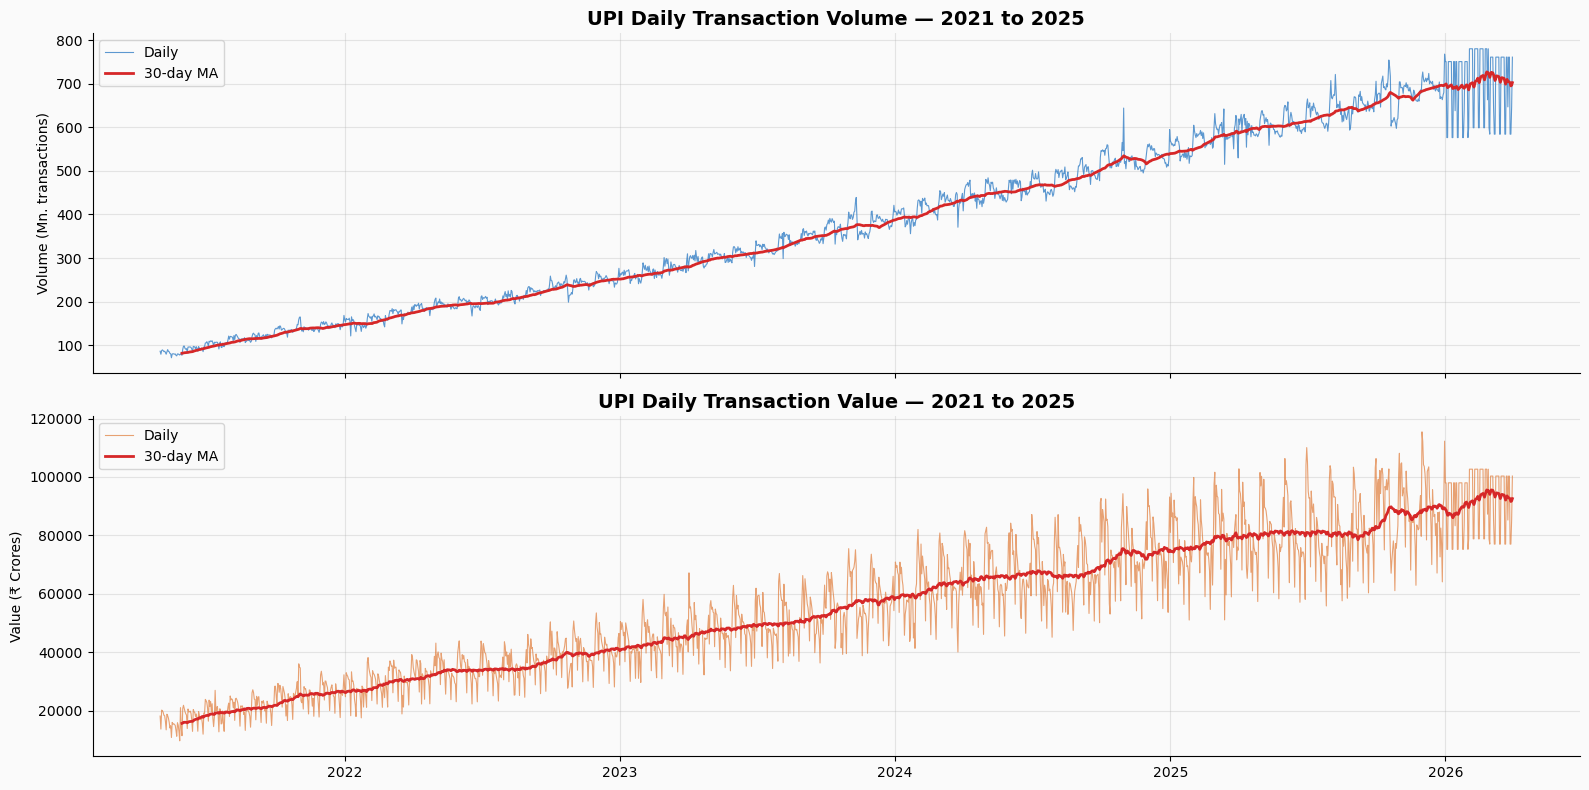

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df["Date"], df["Volume (In Mn.)"], color=BLUE, lw=0.8, alpha=0.7, label="Daily")
axes[0].plot(df["Date"], df["Volume (In Mn.)"].rolling(30).mean(), color=RED, lw=2, label="30-day MA")
axes[0].set_ylabel("Volume (Mn. transactions)")
axes[0].set_title("UPI Daily Transaction Volume — 2021 to 2025", fontsize=14, fontweight="bold")
axes[0].legend()

axes[1].plot(df["Date"], df["Value (In Cr.)"], color=ORANGE, lw=0.8, alpha=0.7, label="Daily")
axes[1].plot(df["Date"], df["Value (In Cr.)"].rolling(30).mean(), color=RED, lw=2, label="30-day MA")
axes[1].set_ylabel("Value (₹ Crores)")
axes[1].set_title("UPI Daily Transaction Value — 2021 to 2025", fontsize=14, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("plots/01_full_trend.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Monthly Aggregated Trend

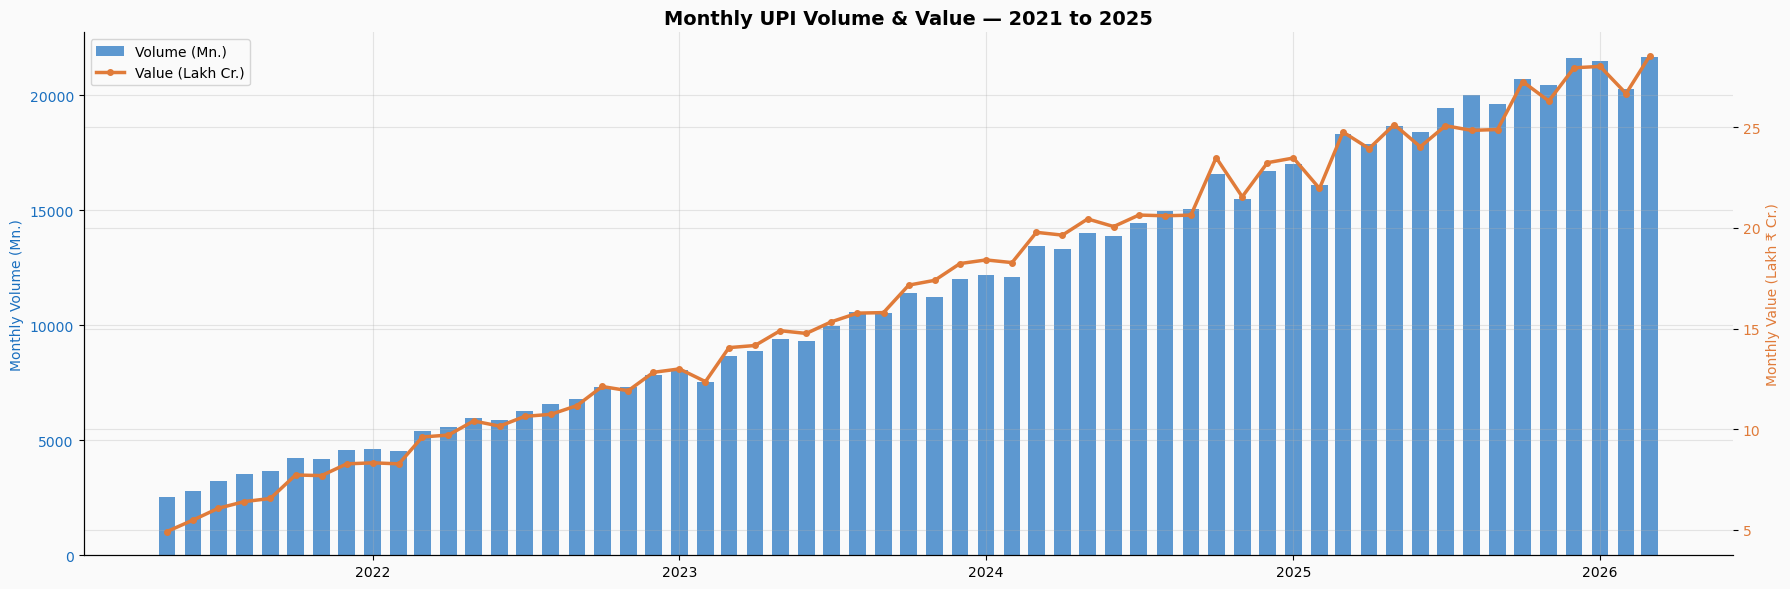

In [6]:
monthly = df.groupby(pd.Grouper(key="Date", freq="MS")).agg(
    Volume=("Volume (In Mn.)", "sum"),
    Value=("Value (In Cr.)", "sum")
).reset_index()

fig, ax1 = plt.subplots(figsize=(18, 6))
ax1.bar(monthly["Date"], monthly["Volume"], width=20, color=BLUE, alpha=0.7, label="Volume (Mn.)")
ax1.set_ylabel("Monthly Volume (Mn.)", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)

ax2 = ax1.twinx()
ax2.plot(monthly["Date"], monthly["Value"]/1e5, color=ORANGE, lw=2.5,
         marker="o", ms=4, label="Value (Lakh Cr.)")
ax2.set_ylabel("Monthly Value (Lakh ₹ Cr.)", color=ORANGE)
ax2.tick_params(axis="y", labelcolor=ORANGE)

ax1.set_title("Monthly UPI Volume & Value — 2021 to 2025", fontsize=14, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left")
plt.tight_layout()
plt.savefig("plots/02_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Year-over-Year Comparison

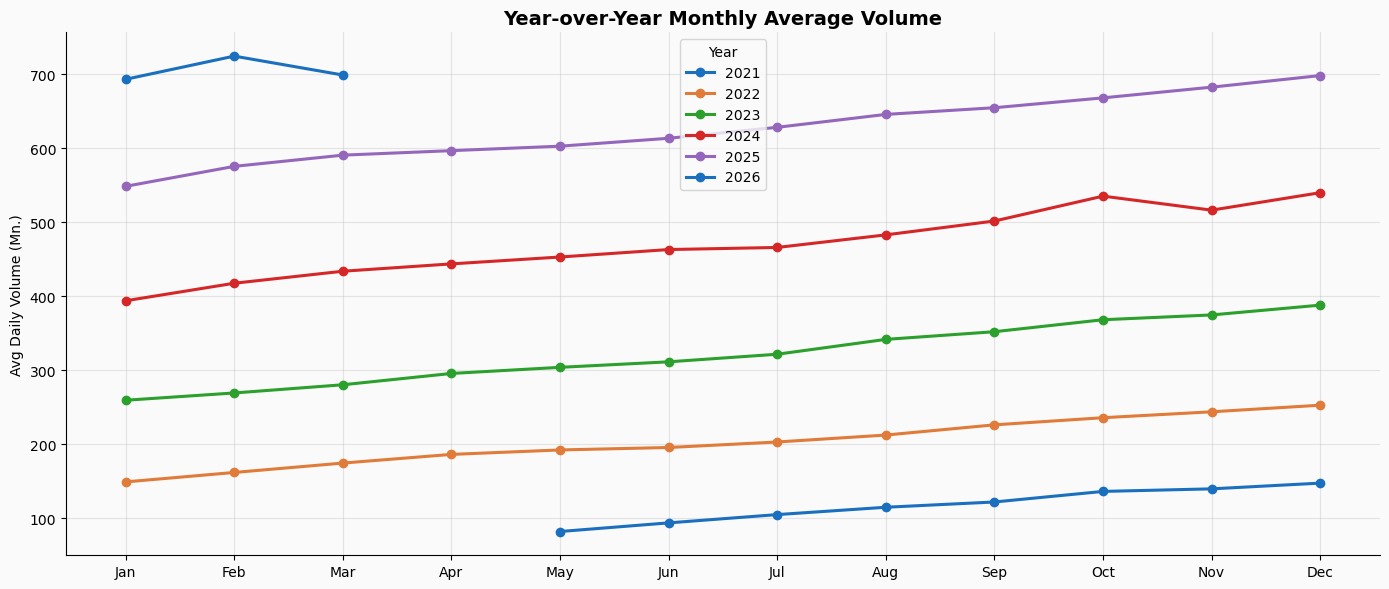

In [7]:
yoy = df.groupby(["YearStr","Month_Num"])["Volume (In Mn.)"].mean().reset_index()
yoy.columns = ["Year","Month","Avg_Volume"]

fig, ax = plt.subplots(figsize=(14, 6))
palette = [BLUE, ORANGE, GREEN, RED, PURPLE]
for i, yr in enumerate(sorted(yoy["Year"].unique())):
    sub = yoy[yoy["Year"]==yr]
    ax.plot(sub["Month"], sub["Avg_Volume"], marker="o", lw=2.2,
            color=palette[i % len(palette)], label=yr)

ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("Avg Daily Volume (Mn.)")
ax.set_title("Year-over-Year Monthly Average Volume", fontsize=14, fontweight="bold")
ax.legend(title="Year")
plt.tight_layout()
plt.savefig("plots/03_yoy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Heatmap — Volume by Month × Year

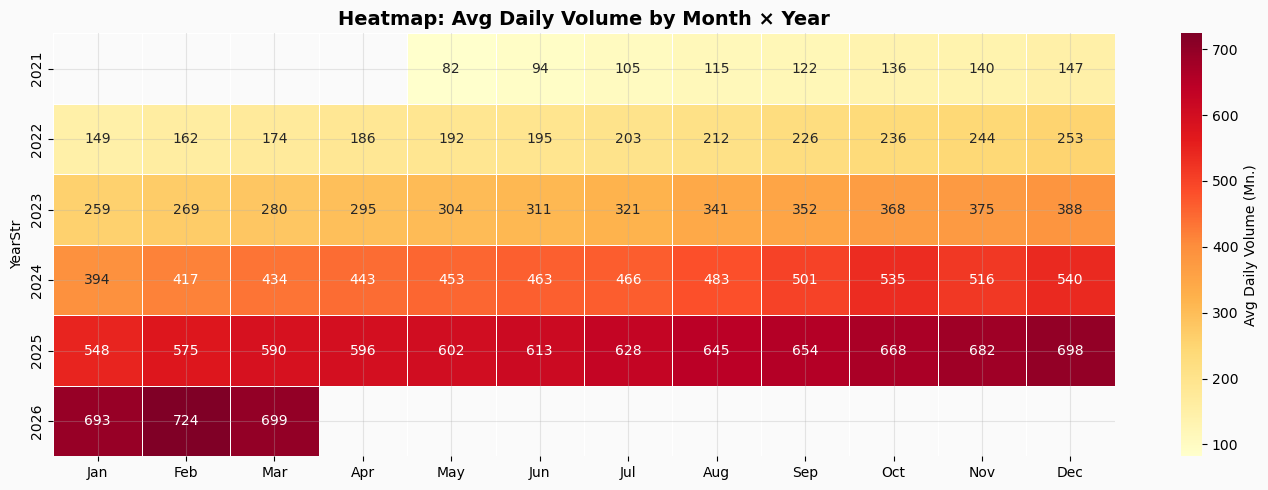

In [8]:
pivot = df.groupby(["YearStr","Month_Num"])["Volume (In Mn.)"].mean().unstack()
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label":"Avg Daily Volume (Mn.)"})
ax.set_title("Heatmap: Avg Daily Volume by Month × Year", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/04_heatmap_volume.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Weekly Patterns

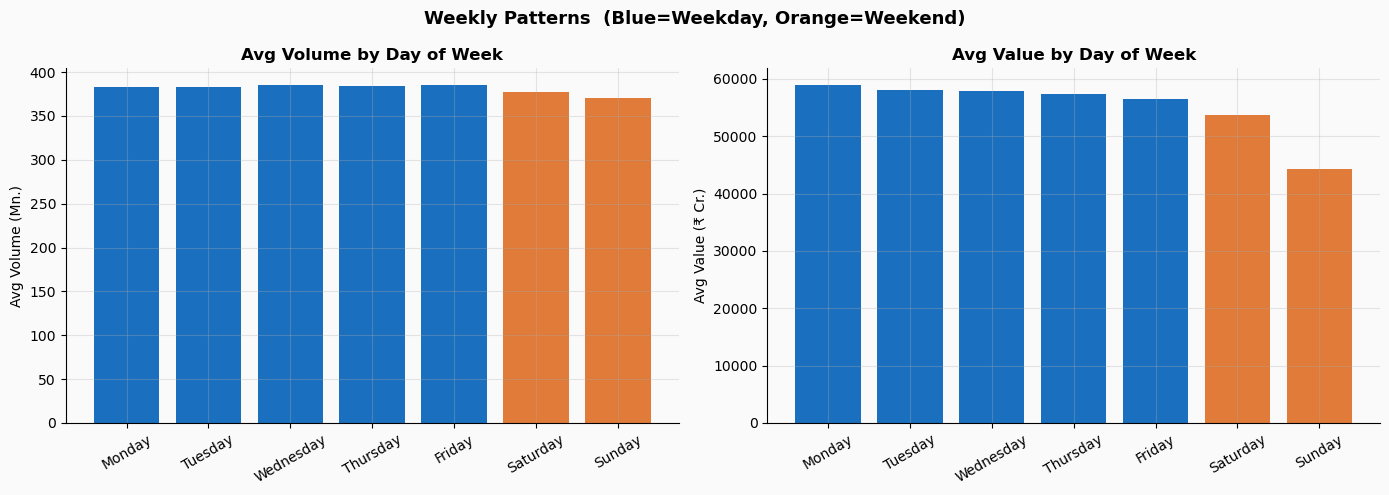

Sunday drop vs Monday: 3.0%


In [9]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_avg   = df.groupby("Day_Name")[["Volume (In Mn.)","Value (In Cr.)"]].mean().reindex(day_order)
colors    = [BLUE if d not in ["Saturday","Sunday"] else ORANGE for d in day_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(day_order, day_avg["Volume (In Mn.)"], color=colors)
axes[0].set_title("Avg Volume by Day of Week", fontweight="bold")
axes[0].set_ylabel("Avg Volume (Mn.)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(day_order, day_avg["Value (In Cr.)"], color=colors)
axes[1].set_title("Avg Value by Day of Week", fontweight="bold")
axes[1].set_ylabel("Avg Value (₹ Cr.)")
axes[1].tick_params(axis="x", rotation=30)

fig.suptitle("Weekly Patterns  (Blue=Weekday, Orange=Weekend)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/05_weekly_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

# Print % drop on Sunday vs Monday
mon_avg = day_avg.loc["Monday","Volume (In Mn.)"]
sun_avg = day_avg.loc["Sunday","Volume (In Mn.)"]
print(f"Sunday drop vs Monday: {(mon_avg-sun_avg)/mon_avg*100:.1f}%")


## 7. Distributions — Histogram + KDE

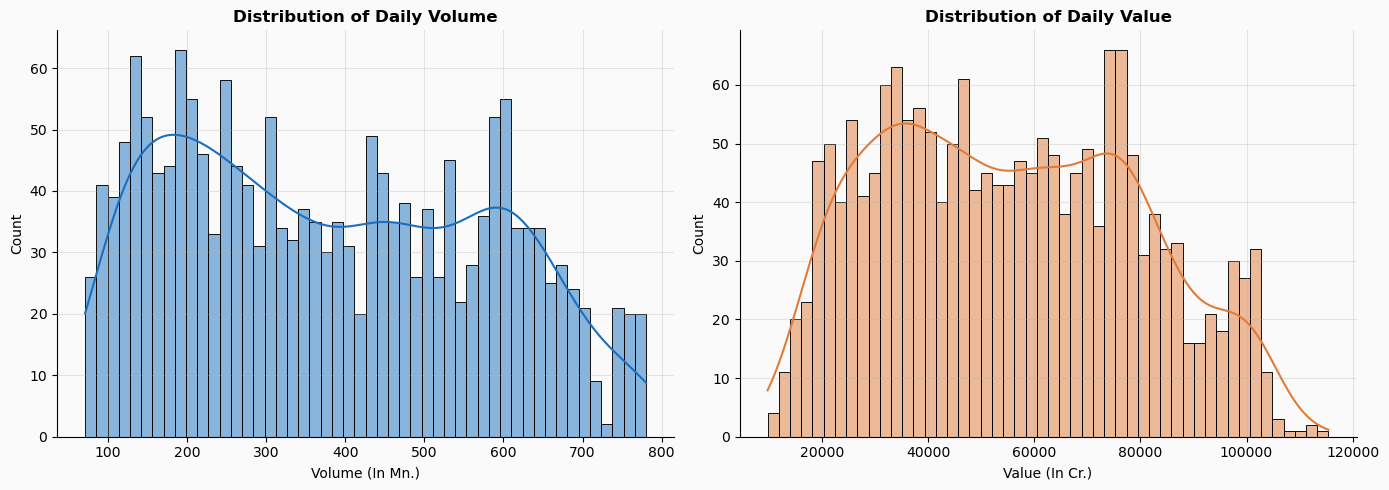

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Volume (In Mn.)"], bins=50, kde=True, color=BLUE, ax=axes[0])
axes[0].set_title("Distribution of Daily Volume", fontweight="bold")

sns.histplot(df["Value (In Cr.)"], bins=50, kde=True, color=ORANGE, ax=axes[1])
axes[1].set_title("Distribution of Daily Value", fontweight="bold")

plt.tight_layout()
plt.savefig("plots/06_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Box Plots by Month

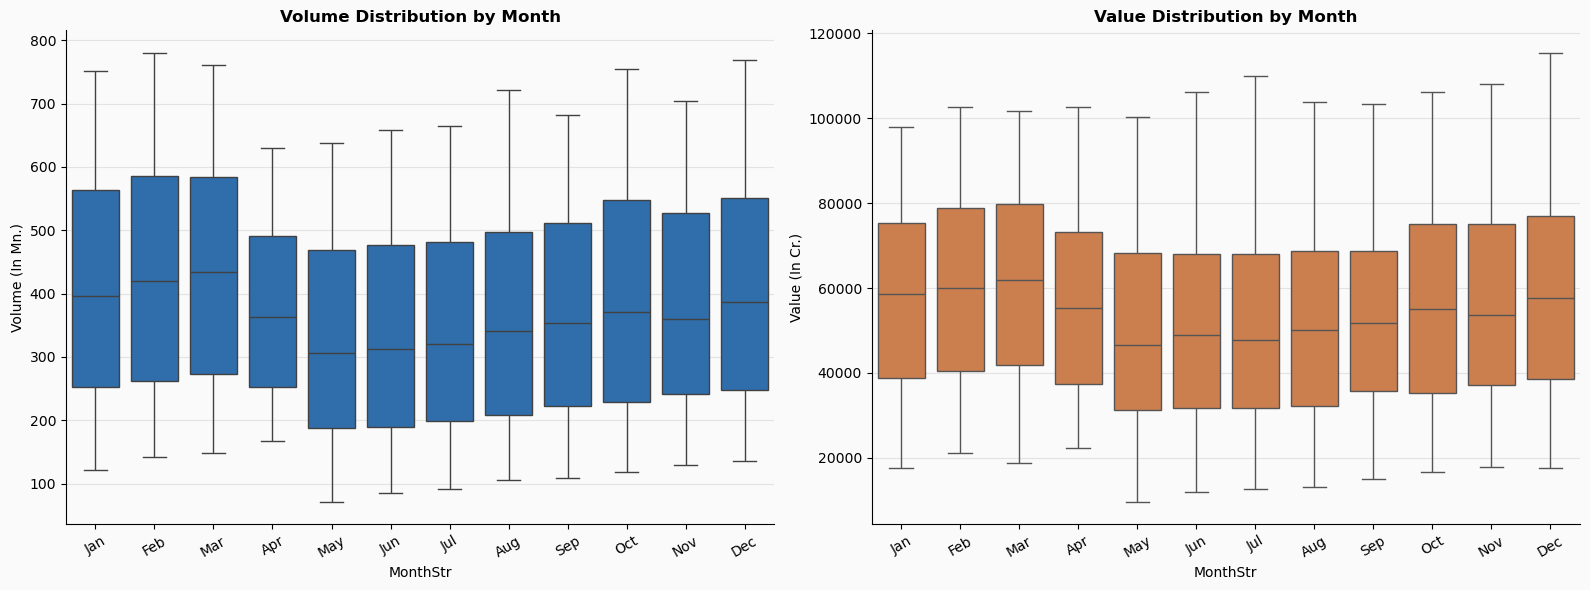

In [11]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
df["MonthStr"] = df["Month_Num"].apply(lambda x: month_names[x-1])
df["MonthStr"] = pd.Categorical(df["MonthStr"], categories=month_names, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x="MonthStr", y="Volume (In Mn.)", ax=axes[0], color=BLUE, fliersize=2)
axes[0].set_title("Volume Distribution by Month", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="MonthStr", y="Value (In Cr.)", ax=axes[1], color=ORANGE, fliersize=2)
axes[1].set_title("Value Distribution by Month", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("plots/07_boxplot_month.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Holiday & Festival Impact

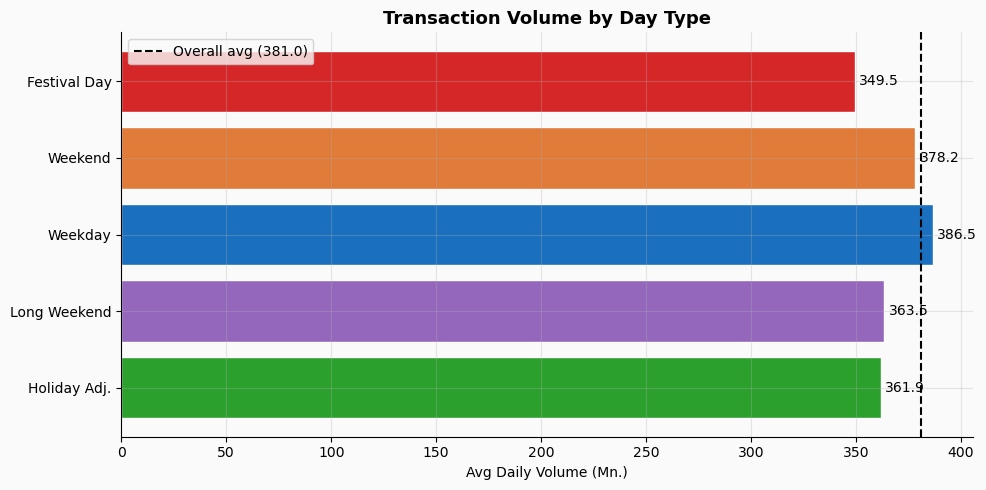

In [12]:
overall_mean = df["Volume (In Mn.)"].mean()
groups = {
    "Festival Day":  df[df["Is_Festival"]==1]["Volume (In Mn.)"],
    "Weekend":       df[(df["Is_Weekend"]==1)&(df["Is_Festival"]==0)]["Volume (In Mn.)"],
    "Weekday":       df[(df["Is_Weekday"]==1)&(df["Is_Festival"]==0)]["Volume (In Mn.)"],
    "Long Weekend":  df[df["Is_Long_Weekend"]==1]["Volume (In Mn.)"],
    "Holiday Adj.":  df[df["Is_Holiday_Adjacent"]==1]["Volume (In Mn.)"],
}
labels = list(groups.keys())
means  = [g.mean() for g in groups.values()]
colors_= [RED, ORANGE, BLUE, PURPLE, GREEN]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, means, color=colors_, edgecolor="white")
for bar, val in zip(bars, means):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=10)
ax.axvline(overall_mean, color="black", lw=1.5, linestyle="--", label=f"Overall avg ({overall_mean:.1f})")
ax.set_xlabel("Avg Daily Volume (Mn.)")
ax.set_title("Transaction Volume by Day Type", fontsize=13, fontweight="bold")
ax.invert_yaxis(); ax.legend()
plt.tight_layout()
plt.savefig("plots/08a_holiday_impact.png", dpi=150, bbox_inches="tight")
plt.show()


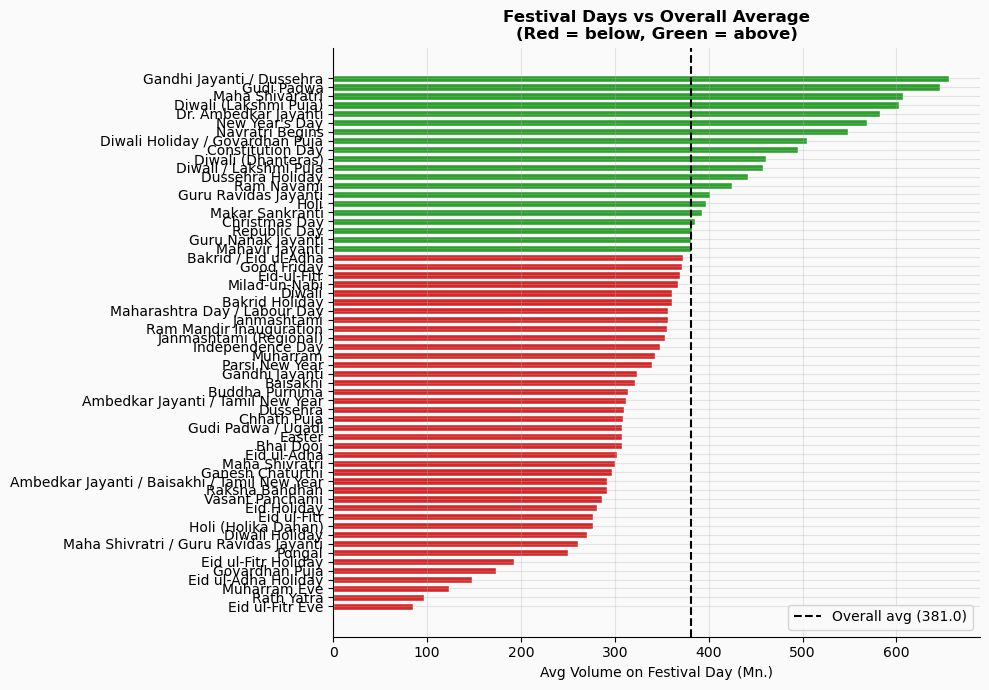

In [13]:
# Top festivals by impact
festival_df = df[df["Festival_Name"]!=""].copy()
fest_avg    = festival_df.groupby("Festival_Name")["Volume (In Mn.)"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_fest = [RED if v < overall_mean else GREEN for v in fest_avg.values]
ax.barh(fest_avg.index, fest_avg.values, color=colors_fest, edgecolor="white")
ax.axvline(overall_mean, color="black", lw=1.5, linestyle="--",
           label=f"Overall avg ({overall_mean:.1f})")
ax.set_xlabel("Avg Volume on Festival Day (Mn.)")
ax.set_title("Festival Days vs Overall Average\n(Red = below, Green = above)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plots/08b_festival_volume.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Rolling Statistics

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

roll7  = df["Volume (In Mn.)"].rolling(7).mean()
roll30 = df["Volume (In Mn.)"].rolling(30).mean()
std30  = df["Volume (In Mn.)"].rolling(30).std()

axes[0].plot(df["Date"], df["Volume (In Mn.)"], color=BLUE, lw=0.6, alpha=0.4, label="Daily")
axes[0].plot(df["Date"], roll7,  color=ORANGE, lw=1.5, label="7-day MA")
axes[0].plot(df["Date"], roll30, color=RED,    lw=2.0, label="30-day MA")
axes[0].set_ylabel("Volume (Mn.)"); axes[0].legend()
axes[0].set_title("Rolling Mean", fontweight="bold")

axes[1].plot(df["Date"], std30, color=PURPLE, lw=1.5)
axes[1].fill_between(df["Date"], 0, std30, color=PURPLE, alpha=0.2)
axes[1].set_ylabel("Std Dev"); axes[1].set_title("30-day Rolling Std Dev", fontweight="bold")

plt.tight_layout()
plt.savefig("plots/09_rolling_stats.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Volume vs Value Correlation

In [ ]:
corr = df["Volume (In Mn.)"].corr(df["Value (In Cr.)"])
print(f"Pearson r (Volume vs Value): {corr:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df["Volume (In Mn.)"], df["Value (In Cr.)"],
                     c=df["Month_Num"], cmap="tab12", alpha=0.5, s=15)
plt.colorbar(scatter, ax=ax, label="Month")
ax.set_xlabel("Volume (Mn.)"); ax.set_ylabel("Value (₹ Cr.)")
ax.set_title(f"Volume vs Value  |  Pearson r = {corr:.4f}", fontweight="bold")
plt.tight_layout()
plt.savefig("plots/10_volume_vs_value.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. CAGR Summary

In [ ]:
yearly = df.groupby(df["Date"].dt.year)["Volume (In Mn.)"].sum()
full   = yearly.loc[2022:2024]
cagr   = ((full.iloc[-1]/full.iloc[0])**(1/(len(full)-1))-1)*100

print("Annual Volume Summary")
print("-"*35)
for yr, vol in yearly.items():
    print(f"  {yr}: {vol:>10,.0f} Mn. transactions")
print(f"\nCAGR (2022–2024): {cagr:.1f}%")
